In [1]:
!pip install -q datasets transformers Pillow torch torchvision open_clip_torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import warnings
warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Device: {DEVICE} | dtype: {DTYPE}")


Device: cpu | dtype: torch.float32


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "MultimodalUniverse/hsc",
    split="train",
    streaming=True,
)

samples = list(ds.take(5))
print(f"\nLoaded {len(samples)} samples")
print("\n=== EXACT KEYS IN SAMPLE 0 ===")
for k, v in samples[0].items():
    try:
        arr = np.array(v)
        print(f"  {k:20s} shape={arr.shape}  dtype={arr.dtype}")
    except Exception:
        print(f"  {k:20s} type={type(v).__name__}  value={str(v)[:60]}")


README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]


Loaded 5 samples

=== EXACT KEYS IN SAMPLE 0 ===
  image                shape=()  dtype=object
  a_g                  shape=()  dtype=float64
  a_r                  shape=()  dtype=float64
  a_i                  shape=()  dtype=float64
  a_z                  shape=()  dtype=float64
  a_y                  shape=()  dtype=float64
  g_extendedness_value shape=()  dtype=float64
  r_extendedness_value shape=()  dtype=float64
  i_extendedness_value shape=()  dtype=float64
  z_extendedness_value shape=()  dtype=float64
  y_extendedness_value shape=()  dtype=float64
  g_cmodel_mag         shape=()  dtype=float64
  g_cmodel_magerr      shape=()  dtype=float64
  r_cmodel_mag         shape=()  dtype=float64
  r_cmodel_magerr      shape=()  dtype=float64
  i_cmodel_mag         shape=()  dtype=float64
  i_cmodel_magerr      shape=()  dtype=float64
  z_cmodel_mag         shape=()  dtype=float64
  z_cmodel_magerr      shape=()  dtype=float64
  y_cmodel_mag         shape=()  dtype=float64
  y_cmodel_

In [4]:
def sample_to_pil(s):
    """
    HSC stores images as dict with key 'image' containing a PIL Image,
    OR as raw numpy flux arrays under key 'image' or 'cutout'.
    This function handles all cases.
    """
    raw = s.get("image") or s.get("cutout") or s.get("img")

    # Already a PIL image
    if isinstance(raw, Image.Image):
        return raw.convert("RGB")

    # It's a dict-like object (common in MultimodalUniverse)
    # HSC image structure: {'array': ndarray of shape (C, H, W)} or similar
    if hasattr(raw, 'keys') or isinstance(raw, dict):
        # Try common sub-keys
        for subkey in ['array', 'flux', 'data', 'pixels']:
            if subkey in raw:
                arr = np.array(raw[subkey])
                return flux_to_pil(arr)
        # Last resort: convert the whole thing
        arr = np.array(list(raw.values())[0])
        return flux_to_pil(arr)

    # It's a numpy array directly
    if raw is not None:
        arr = np.array(raw)
        return flux_to_pil(arr)

    # Absolute fallback: find any array-like value in the sample
    for v in s.values():
        try:
            arr = np.array(v)
            if arr.ndim >= 2:
                return flux_to_pil(arr)
        except Exception:
            continue

    raise ValueError(f"Cannot find image data. Keys: {list(s.keys())}")


def flux_to_pil(arr):
    """Convert a numpy flux array (any shape) to a displayable PIL RGB image."""
    arr = arr.astype(float)

    # (C, H, W) → (H, W, C)
    if arr.ndim == 3 and arr.shape[0] <= 10:
        arr = np.transpose(arr, (1, 2, 0))

    # Multi-band: take first 3 bands as RGB, or just first band as grayscale
    if arr.ndim == 3:
        if arr.shape[2] >= 3:
            arr = arr[:, :, :3]
        else:
            arr = arr[:, :, 0]

    # Normalize per-channel to 0–255
    if arr.ndim == 3:
        out = np.zeros_like(arr)
        for c in range(arr.shape[2]):
            ch = arr[:, :, c]
            lo, hi = np.percentile(ch, 1), np.percentile(ch, 99)
            out[:, :, c] = np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1) * 255
        return Image.fromarray(out.astype(np.uint8), mode="RGB")
    else:
        lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
        norm = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1) * 255
        return Image.fromarray(norm.astype(np.uint8)).convert("RGB")


# Test it
img1 = sample_to_pil(samples[0])
img2 = sample_to_pil(samples[1])
print(f"img1: {img1.size}, mode={img1.mode}")
print(f"img2: {img2.size}, mode={img2.mode}")


img1: (160, 160), mode=RGB
img2: (160, 160), mode=RGB


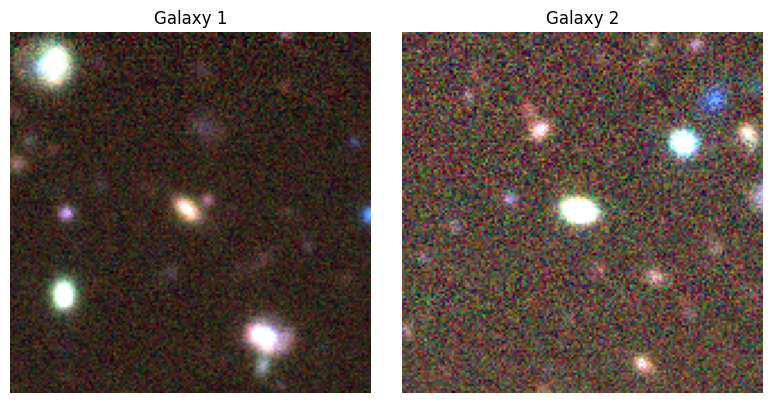

Galaxy images saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img1)
axes[0].set_title("Galaxy 1")
axes[0].axis("off")
axes[1].imshow(img2)
axes[1].set_title("Galaxy 2")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("galaxies.png", dpi=100)
plt.show()
print("Galaxy images saved.")

HSC is image-only → using synthetic spectrum


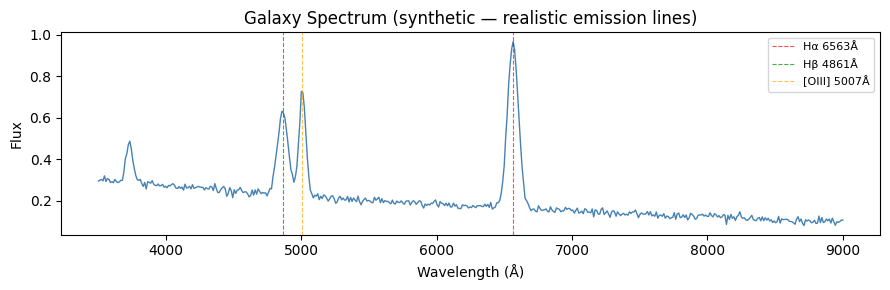

Spectrum saved.


In [6]:
def check_real_spectrum(s):
    """Returns (wavelength, flux) arrays if real spectrum exists, else None."""
    wl = s.get("wavelength") or s.get("wave") or s.get("lambda")
    fl = s.get("spectrum") or s.get("spec_flux")
    if wl is not None and fl is not None:
        wl_arr = np.array(wl)
        fl_arr = np.array(fl)
        # Must be 1D arrays of same length
        if wl_arr.ndim == 1 and fl_arr.ndim == 1 and len(wl_arr) == len(fl_arr):
            return wl_arr, fl_arr
    return None

result = check_real_spectrum(samples[0])

if result:
    wavelength, flux = result
    title = "Galaxy Spectrum (real)"
    print("Using real spectrum data")
else:
    print("HSC is image-only → using synthetic spectrum")
    wavelength = np.linspace(3500, 9000, 500)
    continuum  = 0.3 * np.exp(-(wavelength - 3500) / 5000)
    flux = (
        continuum
        + 0.8 * np.exp(-((wavelength - 6563)**2) / (2*40**2))   # Hα
        + 0.4 * np.exp(-((wavelength - 4861)**2) / (2*40**2))   # Hβ
        + 0.5 * np.exp(-((wavelength - 5007)**2) / (2*25**2))   # [OIII]
        + 0.2 * np.exp(-((wavelength - 3727)**2) / (2*25**2))   # [OII]
        + 0.01 * np.random.randn(500)
    )
    title = "Galaxy Spectrum (synthetic — realistic emission lines)"

plt.figure(figsize=(9, 3))
plt.plot(wavelength, flux, lw=1, color="steelblue")
plt.axvline(6563, color="red",    lw=0.8, ls="--", alpha=0.7, label="Hα 6563Å")
plt.axvline(4861, color="green",  lw=0.8, ls="--", alpha=0.7, label="Hβ 4861Å")
plt.axvline(5007, color="orange", lw=0.8, ls="--", alpha=0.7, label="[OIII] 5007Å")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title(title)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("spectrum.png", dpi=100)
plt.show()
print("Spectrum saved.")

Kepler unavailable (Dataset 'MultimodalUniverse/kepler' doesn't exist on the Hub or cannot be accessed.) → synthetic fallback
Using synthetic exoplanet transit light curve


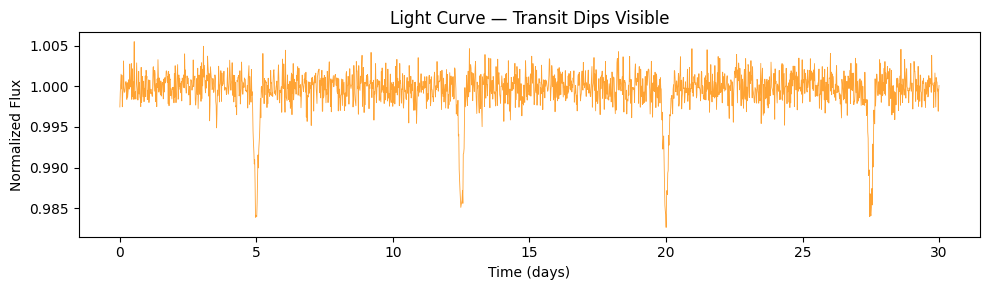

Light curve saved.


In [7]:
lc_loaded = False
try:
    lc_ds = load_dataset("MultimodalUniverse/kepler", split="train", streaming=True)
    lc_sample = next(iter(lc_ds))
    print("Kepler keys:", list(lc_sample.keys()))

    # Find time and flux arrays
    time_arr = None
    flux_arr = None
    for tk in ["time", "t", "bjd", "cadenceno"]:
        if tk in lc_sample:
            time_arr = np.array(lc_sample[tk])
            break
    for fk in ["flux", "sap_flux", "pdcsap_flux", "brightness"]:
        if fk in lc_sample:
            flux_arr = np.array(lc_sample[fk])
            break

    if time_arr is not None and flux_arr is not None:
        # Remove NaNs
        mask = np.isfinite(time_arr) & np.isfinite(flux_arr)
        time_arr, flux_arr = time_arr[mask], flux_arr[mask]
        # Normalize flux to ~1.0
        flux_arr = flux_arr / np.median(flux_arr)
        lc_loaded = True
        print("Real Kepler light curve loaded.")

except Exception as e:
    print(f"Kepler unavailable ({e}) → synthetic fallback")

if not lc_loaded:
    print("Using synthetic exoplanet transit light curve")
    time_arr = np.linspace(0, 30, 2000)
    flux_arr = np.ones(2000)
    for center in [5.0, 12.5, 20.0, 27.5]:
        flux_arr -= 0.015 * np.exp(-((time_arr - center)**2) / (2 * 0.08**2))
    flux_arr += 0.0015 * np.random.randn(2000)

plt.figure(figsize=(10, 3))
plt.plot(time_arr, flux_arr, lw=0.6, color="darkorange", alpha=0.8)
plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Light Curve — Transit Dips Visible")
plt.tight_layout()
plt.savefig("light_curve.png", dpi=100)
plt.show()
print("Light curve saved.")

In [8]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

print(f"Loading BLIP-2 on {DEVICE} with {DTYPE}...")
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=DTYPE
).to(DEVICE)
print("BLIP-2 ready.")

inputs = processor(img1, "Question: What do you see in this image? Answer:",
                   return_tensors="pt").to(DEVICE, DTYPE)
out = blip_model.generate(**inputs, max_new_tokens=60)
caption = processor.decode(out[0], skip_special_tokens=True)
print(f"\nCaption for Galaxy 1:\n  → {caption}")


Loading BLIP-2 on cpu with torch.float32...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 ready.

Caption for Galaxy 1:
  → Question: What do you see in this image? Answer: a cluster of galaxies



In [9]:
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model.eval()

def get_clip_embedding(pil_img):
    tensor = clip_preprocess(pil_img).unsqueeze(0)
    with torch.no_grad():
        emb = clip_model.encode_image(tensor)
    emb = emb / emb.norm(dim=-1, keepdim=True)  # L2 normalize
    return emb.squeeze().numpy()

emb1 = get_clip_embedding(img1)
emb2 = get_clip_embedding(img2)
print(f"Embedding shape: {emb1.shape}")
print(f"First 5 values of emb1: {emb1[:5].round(4)}")


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Embedding shape: (512,)
First 5 values of emb1: [ 0.0009 -0.0459  0.0411 -0.0059 -0.0153]


In [10]:
from numpy.linalg import norm

def cosine_sim(a, b):
    # embeddings are already L2-normalized so dot product = cosine sim
    return float(np.dot(a, b))

sim = cosine_sim(emb1, emb2)
print(f"\nCosine similarity (Galaxy 1 vs Galaxy 2): {sim:.4f}")
if   sim > 0.85: print("→ Very similar (same morphological type)")
elif sim > 0.60: print("→ Moderately similar")
else:            print("→ Quite different galaxy types")



Cosine similarity (Galaxy 1 vs Galaxy 2): 0.9517
→ Very similar (same morphological type)


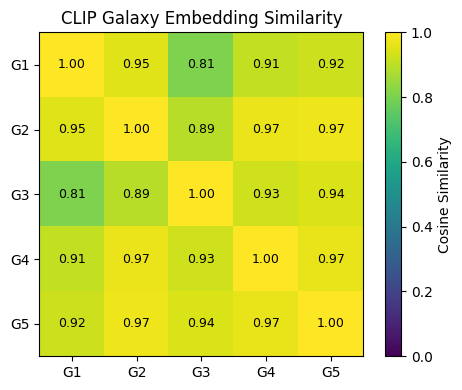

Similarity matrix saved.


In [11]:
all_imgs = [sample_to_pil(s) for s in samples]
all_embs = [get_clip_embedding(im) for im in all_imgs]

n = len(all_embs)
sim_matrix = np.array([[cosine_sim(all_embs[i], all_embs[j])
                         for j in range(n)] for i in range(n)])

fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.imshow(sim_matrix, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(cax, ax=ax, label="Cosine Similarity")
ax.set_xticks(range(n)); ax.set_xticklabels([f"G{i+1}" for i in range(n)])
ax.set_yticks(range(n)); ax.set_yticklabels([f"G{i+1}" for i in range(n)])
ax.set_title("CLIP Galaxy Embedding Similarity")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center",
                color="white" if sim_matrix[i,j] < 0.6 else "black", fontsize=9)
plt.tight_layout()
plt.savefig("similarity_matrix.png", dpi=100)
plt.show()
print("Similarity matrix saved.")